# Setup

In [28]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LassoCV
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({'figure.figsize': (13, 5.5), 'font.size': 11})

# -- Load data --
import os
LOCAL_DATA = "../Data/alpha_dataset_v2.csv"
df = pd.read_csv(LOCAL_DATA)
print(f"Dataset: {df.shape[0]:,} rows, {df.shape[1]} cols, {df['ym'].nunique()} months")

TRAIN_TARGET = 'y_xs'
EVAL_TARGET = 'y_raw'
OOS_START = '2015-01'
K = 30

df_sp = df.copy()
print(f"Universe: {df_sp['permno'].nunique()} stocks")

# SPY benchmark
ff = df_sp.groupby('ym')[['Mkt_RF', 'rf_ff']].first().sort_index()
ff['spy_ret'] = ff['Mkt_RF'] + ff['rf_ff']
spy_oos = ff.loc[ff.index >= OOS_START, 'spy_ret']
spy_cum = (1 + spy_oos).cumprod()
spy_sr = spy_oos.mean() / spy_oos.std() * np.sqrt(12)
print(f"SPY OOS: {len(spy_oos)} months, SR = {spy_sr:.2f}")


Dataset: 257,800 rows, 229 cols, 407 months
Universe: 1216 stocks
SPY OOS: 107 months, SR = 0.73


In [29]:
# -- Helper functions --

def select_topk_capped(df_month, pred_col, K, sector_cap=None):
    """Select top-K stocks by prediction, with optional sector cap.

    Greedy: walk down the ranked list, skip stocks whose sector is full.
    If sector_cap is None, just takes top K.
    """
    ranked = df_month.sort_values(pred_col, ascending=False)
    if sector_cap is None:
        return ranked.head(K)

    selected = []
    sector_counts = {}
    for idx, row in ranked.iterrows():
        sec = row.get('sector', 'Unknown')
        count = sector_counts.get(sec, 0)
        if count < sector_cap:
            selected.append(idx)
            sector_counts[sec] = count + 1
            if len(selected) == K:
                break
    return df_month.loc[selected]


def perf(s, name=''):
    """Annualized performance stats."""
    mu = s.mean() * 12
    vol = s.std() * np.sqrt(12)
    sr = mu / vol if vol > 0 else 0
    cum = (1 + s).cumprod()
    mdd = (cum / cum.cummax() - 1).min()
    return {'Strategy': name, 'SR': round(sr, 2), 'Ann Mean': f'{mu:.1%}',
            'Ann Vol': f'{vol:.1%}', 'MDD': f'{mdd:.1%}',
            'Total': f'{cum.iloc[-1]-1:.0%}'}


def plot_strats(strat_dict, title):
    """Plot cumulative wealth for multiple strategies + SPY."""
    fig, ax = plt.subplots(figsize=(13, 5.5))
    for name, s in strat_dict.items():
        cum = (1 + s).cumprod()
        sr = s.mean() / s.std() * np.sqrt(12) if s.std() > 0 else 0
        ax.plot(cum.index, cum.values, label=f'{name} (SR={sr:.2f})', linewidth=1.3)
    ax.plot(spy_cum.index, spy_cum.values, color='gray', linestyle='--',
            linewidth=2.2, label=f'SPY (SR={spy_sr:.2f})', alpha=0.8)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Cumulative Wealth ($1)')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(alpha=0.3)
    ticks = list(range(0, len(ax.get_xticks()), max(1, len(ax.get_xticks()) // 15)))
    ax.set_xticks([ax.get_xticks()[i] for i in ticks if i < len(ax.get_xticks())])
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()

print("Helper functions loaded.")



Helper functions loaded.


In [30]:
# -- Enhanced Helper functions --
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

def compute_monthly_ic(predictions: pd.Series, returns: pd.Series):
    """Monthly cross-sectional Spearman IC with diagnostics - works with your data"""
    ic_list = []
    dates = []
    
    # Group by ym (month)
    for ym, group in predictions.groupby(predictions.index.get_level_values(0) if isinstance(predictions.index, pd.MultiIndex) else test['ym']):
        if isinstance(predictions.index, pd.MultiIndex):
            pred = predictions.loc[ym]
            ret = returns.loc[ym]
        else:
            # Fallback for single index case
            pred = predictions[predictions.index == ym] if ym in predictions.index else predictions
            ret = returns[returns.index == ym] if ym in returns.index else returns
        
        if len(pred) > 20:
            ic, _ = spearmanr(pred.values, ret.values)
            ic_list.append(ic)
            dates.append(ym)
    
    ic_series = pd.Series(ic_list, index=dates)
    
    mean_ic = ic_series.mean()
    ic_std = ic_series.std()
    icir = mean_ic / ic_std if ic_std > 0 else 0
    t_stat = icir * np.sqrt(len(ic_series))
    hit_rate = (ic_series > 0).mean()
    
    print(f"IC Diagnostics → Mean IC: {mean_ic:.4f} | ICIR: {icir:.3f} | t-stat: {t_stat:.2f} | Hit Rate: {hit_rate:.1%}")
    return ic_series

def plot_cumulative_ic(ic_series, title="Cumulative IC"):
    cum_ic = ic_series.cumsum()
    plt.figure(figsize=(13, 5))
    plt.plot(cum_ic.index, cum_ic.values, linewidth=2)
    plt.title(title)
    plt.axhline(0, color='red', linestyle='--', alpha=0.7)
    plt.grid(alpha=0.3)
    plt.ylabel('Cumulative IC')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def perf(s, name=''):
    mu = s.mean() * 12
    vol = s.std() * np.sqrt(12)
    sr = mu / vol if vol > 0 else 0
    cum = (1 + s).cumprod()
    mdd = (cum / cum.cummax() - 1).min()
    return {'Strategy': name, 'SR': round(sr, 2), 'Ann Mean': f'{mu:.1%}',
            'Ann Vol': f'{vol:.1%}', 'MDD': f'{mdd:.1%}', 'Total': f'{cum.iloc[-1]-1:.0%}'}

def plot_strats(strat_dict, title):
    fig, ax = plt.subplots(figsize=(13, 5.5))
    for name, s in strat_dict.items():
        cum = (1 + s).cumprod()
        sr = s.mean() / s.std() * np.sqrt(12) if s.std() > 0 else 0
        ax.plot(cum.index, cum.values, label=f'{name} (SR={sr:.2f})', linewidth=1.3)
    ax.plot(spy_cum.index, spy_cum.values, color='gray', linestyle='--', linewidth=2.2,
            label=f'SPY (SR={spy_sr:.2f})', alpha=0.8)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Cumulative Wealth ($1)')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(alpha=0.3)
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()

print("Enhanced helpers loaded (with IC diagnostics).")

Enhanced helpers loaded (with IC diagnostics).


# Feature Engineering

In [31]:
# ── Feature Engineering ──────────────────────────────────────────────

def _get_existing(df_slice, cols):
    """Return DataFrame of only the columns that actually exist. No zero-padding."""
    return df_slice[[c for c in cols if c in df_slice.columns]]


def _build_engineered_features(df_slice):
    """Build all engineered features (shared by both tiers)."""
    feat = pd.DataFrame(index=df_slice.index)

    # Helper: get column or zeros (for individual features, not composites)
    def _s(col):
        return df_slice[col] if col in df_slice.columns else pd.Series(0.0, index=df_slice.index)

    # ── 1. Interaction terms ─────────────────────────────────────
    # Momentum × Quality: momentum more reliable in quality firms
    feat['mom_x_quality'] = _s('ret_2_12_xs') * _s('gpa_xs')
    feat['mom_x_roe'] = _s('ret_2_12_xs') * _s('roe_xs')

    # Value × Low-volatility: value stronger in stable firms
    feat['val_x_lowvol'] = _s('bm_xs') * (-_s('vol_12m_xs'))
    feat['ep_x_lowvol'] = _s('ep_xs') * (-_s('vol_12m_xs'))

    # Earnings surprise × Analyst signals
    feat['sue_x_lowdisp'] = _s('sue_xs') * (-_s('dispersion_xs'))
    feat['sue_x_revision'] = _s('sue_xs') * _s('revision_xs')

    # Momentum × Low idiosyncratic vol
    feat['mom_x_lowivol'] = _s('ret_2_12_xs') * (-_s('ivol_xs'))

    # Value × Profitability: cheap + profitable = classic quality-value
    feat['bm_x_roe'] = _s('bm_xs') * _s('roe_xs')
    feat['ep_x_gpa'] = _s('ep_xs') * _s('gpa_xs')

    # ── 2. Non-linear transforms (for Lasso — HGB can learn these but they don't hurt)
    for col in ['ret_2_12_xs', 'ret_1_xs', 'sue_xs', 'bm_xs', 'revision_xs']:
        raw = _s(col)
        feat[f'{col}_sq'] = raw ** 2 * np.sign(raw)

    # ── 3. Composite signals (average only existing columns) ─────
    earn_cols = ['sue_xs', 'sue_q_xs', 'rev_surp_xs', 'earn_growth_yoy_xs', 'beat_xs']
    feat['earnings_composite'] = _get_existing(df_slice, earn_cols).mean(axis=1)

    qual_cols = ['gpa_xs', 'roe_xs', 'roa_xs', 'earn_quality_xs', 'cfo_at_xs']
    feat['quality_composite'] = _get_existing(df_slice, qual_cols).mean(axis=1)

    val_cols = ['bm_xs', 'ep_xs', 'cfp_xs', 'sp_xs']
    feat['value_composite'] = _get_existing(df_slice, val_cols).mean(axis=1)

    mom_cols = ['ret_2_12_xs', 'ret_2_6_xs', 'ret_13_36_xs', 'prc_52w_high_xs']
    feat['momentum_composite'] = _get_existing(df_slice, mom_cols).mean(axis=1)

    tech_cols = ['rsi_14_xs', 'macd_hist_xs', 'bb_position_xs', 'roc_3_xs', 'roc_6_xs']
    feat['technical_composite'] = _get_existing(df_slice, tech_cols).mean(axis=1)

    analyst_cols = ['revision_xs', 'revision_ratio_xs', 'rec_chg_xs', 'n_analysts_xs']
    feat['analyst_composite'] = _get_existing(df_slice, analyst_cols).mean(axis=1)

    # ── 4. Relative / differential signals ──────────────────────
    # Peer-relative: same concept, same horizon — clean subtraction
    feat['sue_vs_peer'] = _s('sue_xs') - _s('peer_sue_xs')
    feat['revision_vs_peer'] = _s('revision_xs') - _s('peer_revision_xs')

    # Reversal-momentum combo (well-documented factor)
    feat['reversal_mom_combo'] = _s('ret_2_12_xs') - _s('ret_1_xs')

    # ── 5. Composite interactions ────────────────────────────────
    feat['earn_x_mom'] = feat['earnings_composite'] * feat['momentum_composite']
    feat['quality_x_value'] = feat['quality_composite'] * feat['value_composite']
    feat['earn_x_lowvol'] = feat['earnings_composite'] * (-_s('vol_12m_xs'))

    return feat.fillna(0.0)


def build_features_linear(df_slice):
    """Tier 1: Conservative feature set for Lasso."""
    feat = pd.DataFrame(index=df_slice.index)

    core = [
        'ret_1_xs', 'ret_2_12_xs', 'ret_2_6_xs',
        'bm_xs', 'ep_xs', 'cfp_xs', 'sp_xs',
        'gpa_xs', 'roe_xs', 'roa_xs',
        'vol_12m_xs', 'ivol_xs', 'beta_xs',
        'log_me_xs',
        'sue_xs', 'revision_xs', 'beat_xs',
        'turnover_xs', 'illiq_12m_xs',
        'mom_x_size_xs', 'val_x_prof_xs', 'mom_x_vol_xs',
        'ret_vs_sector_xs', 'bm_vs_sector_xs', 'ret_vs_ind_xs',
        'bm_vs_size_xs',
    ]
    for c in core:
        if c in df_slice.columns:
            feat[c] = df_slice[c]

    eng = _build_engineered_features(df_slice)
    feat = pd.concat([feat, eng], axis=1)
    return feat.fillna(0.0)


def build_features_ensemble(df_slice):
    """Tier 2: All raw _xs features + engineered features for HGB."""
    xs_cols = [c for c in df_slice.columns if c.endswith('_xs') and c != 'y_xs']
    feat = df_slice[xs_cols].copy()

    eng = _build_engineered_features(df_slice)
    feat = pd.concat([feat, eng], axis=1)
    return feat.fillna(0.0)


print(f"Tier 1 features: {build_features_linear(df_sp).shape[1]}")
print(f"Tier 2 features: {build_features_ensemble(df_sp).shape[1]}")

Tier 1 features: 52
Tier 2 features: 118


# Walk-forward Engine

In [32]:
from sklearn.base import clone
import pandas as pd

# Ensure trailing SPY vol exists
if 'trailing_spy_vol' not in globals():
    _spy_monthly = ff['spy_ret']
    trailing_spy_vol = _spy_monthly.rolling(3).std() * np.sqrt(12)
    trailing_spy_vol = trailing_spy_vol.to_dict()
    print("✅ Trailing SPY vol precomputed.")


def compute_monthly_ic(predictions: pd.Series, returns: pd.Series, ym_series: pd.Series = None):
    """Safe monthly IC computation"""
    ic_list = []
    dates = []
    
    if ym_series is None:
        ym_series = test['ym'] if 'test' in locals() else predictions.index  # fallback
    
    for ym in sorted(ym_series.unique()):
        mask = (ym_series == ym)
        pred = predictions[mask]
        ret = returns[mask]
        
        if len(pred) > 20:
            ic, _ = spearmanr(pred.values, ret.values)
            ic_list.append(ic)
            dates.append(ym)
    
    ic_series = pd.Series(ic_list, index=dates)
    
    mean_ic = ic_series.mean()
    ic_std = ic_series.std()
    icir = mean_ic / ic_std if ic_std > 0 else 0
    t_stat = icir * np.sqrt(len(ic_series))
    hit_rate = (ic_series > 0).mean()
    
    print(f"IC Diagnostics → Mean IC: {mean_ic:.4f} | ICIR: {icir:.3f} | t-stat: {t_stat:.2f} | Hit Rate: {hit_rate:.1%}")
    return ic_series


def run_model_improved(df_in, feature_builder, estimator, name, K=30, sector_cap=5,
                       retrain_every=12, vol_tilt=0.06, vol_threshold=0.17):
    """Clean improved walk-forward with hybrid retraining + IC monitoring"""
    all_months = sorted(df_in['ym'].unique())
    oos_months = [m for m in all_months if m >= OOS_START]
    
    long_only_rets = {}
    ic_series_all = []
    last_retrain = None
    model = None

    for i, m in enumerate(oos_months):
        # Hybrid retraining logic
        if (last_retrain is None or 
            (i % retrain_every == 0) or 
            (len(ic_series_all) >= 12 and pd.Series(ic_series_all[-12:]).mean() < -0.005)):
            
            train = df_in[df_in['ym'] < m].dropna(subset=[TRAIN_TARGET])
            model = clone(estimator)
            model.fit(feature_builder(train), train[TRAIN_TARGET])
            last_retrain = m
            print(f"  [{name}] Retrained up to {m} ({len(train):,} samples)")

        test = df_in[df_in['ym'] == m].copy()
        if len(test) < 2 * K:
            continue

        test['pred'] = model.predict(feature_builder(test))

        # Volatility tilt
        if vol_tilt > 0 and 'vol_12m_xs' in test.columns:
            spy_vol = trailing_spy_vol.get(m, 0)
            if vol_threshold is None or spy_vol > vol_threshold:
                test['pred'] = test['pred'] - vol_tilt * test['vol_12m_xs'].fillna(0)

        # Top-K selection with sector cap
        top = select_topk_capped(test, 'pred', K, sector_cap=sector_cap)
        long_only_rets[m] = top[EVAL_TARGET].mean()

        # IC calculation
        ic_series = compute_monthly_ic(test['pred'], test[EVAL_TARGET], test['ym'])
        if len(ic_series) > 0:
            ic_series_all.extend(ic_series.tolist())

    lo = pd.Series(long_only_rets).sort_index()
    
    print(f"\n=== {name} Complete ===")
    print(perf(lo, name))
    
    if ic_series_all:
        plot_cumulative_ic(pd.Series(ic_series_all), f"Cumulative IC - {name}")
    
    return {'long_only': lo}

print("✅ Cleaned & fixed run_model_improved loaded.")

✅ Cleaned & fixed run_model_improved loaded.


In [33]:
# Initialize results dictionary
results = {}

print("✅ results dictionary initialized.")

✅ results dictionary initialized.



=== Running Optimized HGB with IC Monitoring ===


  [HGB_optimized] Retrained up to 2015-01 (192,712 samples)
IC Diagnostics → Mean IC: -0.0131 | ICIR: 0.000 | t-stat: 0.00 | Hit Rate: 0.0%
IC Diagnostics → Mean IC: 0.0868 | ICIR: 0.000 | t-stat: 0.00 | Hit Rate: 100.0%
IC Diagnostics → Mean IC: -0.1090 | ICIR: 0.000 | t-stat: 0.00 | Hit Rate: 0.0%
IC Diagnostics → Mean IC: 0.1927 | ICIR: 0.000 | t-stat: 0.00 | Hit Rate: 100.0%
IC Diagnostics → Mean IC: 0.1358 | ICIR: 0.000 | t-stat: 0.00 | Hit Rate: 100.0%
IC Diagnostics → Mean IC: 0.0990 | ICIR: 0.000 | t-stat: 0.00 | Hit Rate: 100.0%
IC Diagnostics → Mean IC: -0.0156 | ICIR: 0.000 | t-stat: 0.00 | Hit Rate: 0.0%
IC Diagnostics → Mean IC: 0.0804 | ICIR: 0.000 | t-stat: 0.00 | Hit Rate: 100.0%
IC Diagnostics → Mean IC: -0.0326 | ICIR: 0.000 | t-stat: 0.00 | Hit Rate: 0.0%
IC Diagnostics → Mean IC: 0.1045 | ICIR: 0.000 | t-stat: 0.00 | Hit Rate: 100.0%
IC Diagnostics → Mean IC: 0.0648 | ICIR: 0.000 | t-stat: 0.00 | Hit Rate: 100.0%
IC Diagnostics → Mean IC: 0.0496 | ICIR: 0.000 | t-st

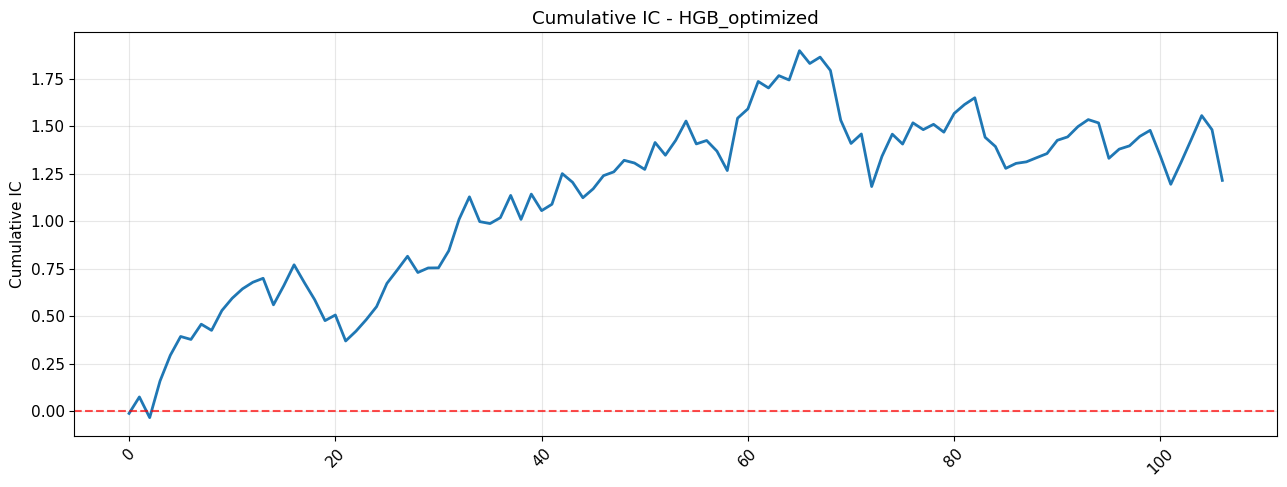

In [34]:
hgb_optimized = HistGradientBoostingRegressor(
    max_iter=500, max_depth=3, learning_rate=0.05,
    min_samples_leaf=500, l2_regularization=0.1,
    early_stopping=False, validation_fraction=0.15, random_state=14
)

print("\n=== Running Optimized HGB with IC Monitoring ===")
results['HGB_optimized'] = run_model_improved(
    df_sp, build_features_ensemble, hgb_optimized, "HGB_optimized", 
    K=30, sector_cap = 5, retrain_every = 12, vol_tilt = 0.05, vol_threshold= None
)

# Summary of results


BEST STRATEGY: HGB_optimized
                 SR Ann Mean Ann Vol     MDD Total
Strategy                                          
HGB_optimized  0.94    19.7%   21.0%  -27.8%  374%
SPY            0.73    11.9%   16.4%  -24.8%  156%


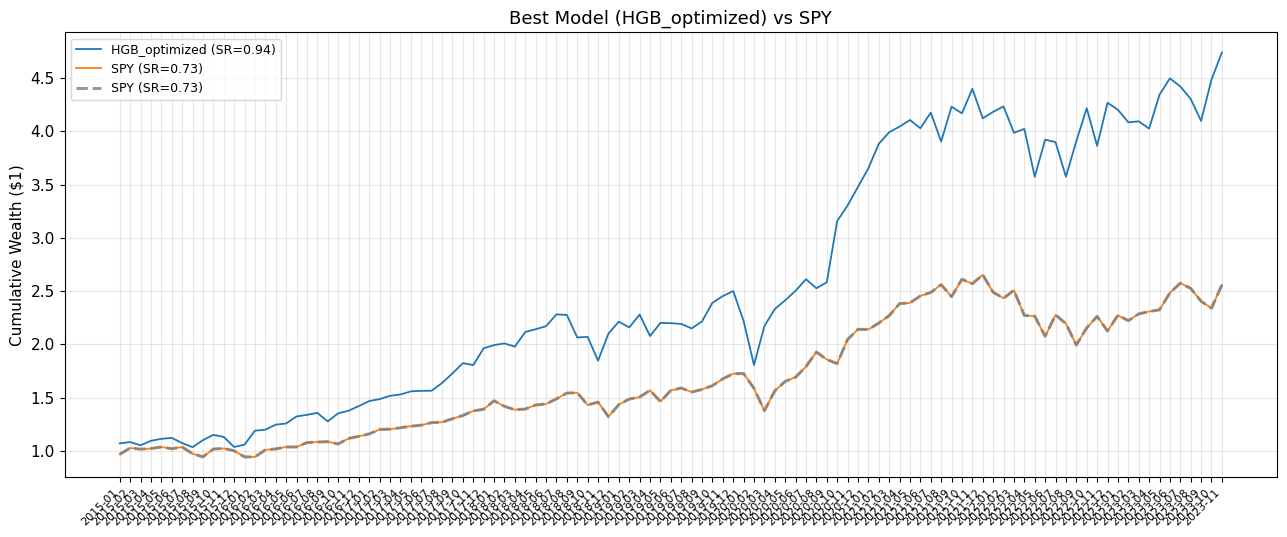

In [35]:
# Final summary with best model
best_name = max(results.keys(), key=lambda k: 
                results[k]['long_only'].mean() / results[k]['long_only'].std() * np.sqrt(12) 
                if results[k]['long_only'].std() > 0 else -999)

best_lo = results[best_name]['long_only']
print(f"\nBEST STRATEGY: {best_name}")
final_perf = pd.DataFrame([perf(best_lo, best_name), perf(spy_oos, 'SPY')]).set_index('Strategy')
print(final_perf.to_string())

plot_strats({best_name: best_lo, 'SPY': spy_oos}, f'Best Model ({best_name}) vs SPY')

BEST STRATEGY: HGB_optimized (SR = 0.94)
SPY Benchmark SR = 0.73
Alpha over SPY = +0.21 SR

                 SR Ann Mean Ann Vol     MDD Total
Strategy                                          
HGB_optimized  0.94    19.7%   21.0%  -27.8%  374%
SPY            0.73    11.9%   16.4%  -24.8%  156%


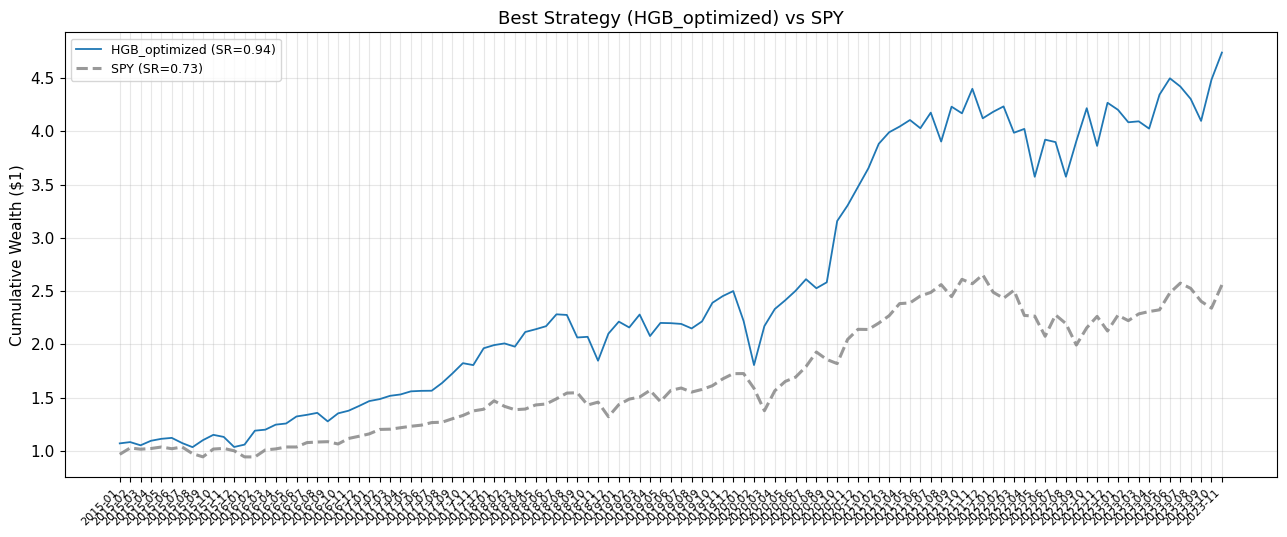

In [36]:

# Pick the best strategy (highest SR with MDD < 40%)
best_name = None
best_sr = -999

for name, res in results.items():
    if 'long_only' not in res:
        continue
    lo = res['long_only']
    sr = lo.mean() / lo.std() * np.sqrt(12) if lo.std() > 0 else 0
    cum = (1 + lo).cumprod()
    mdd = (cum / cum.cummax() - 1).min()
    if mdd > -0.40 and sr > best_sr:
        best_sr = sr
        best_name = name

print(f"BEST STRATEGY: {best_name} (SR = {best_sr:.2f})")
print(f"SPY Benchmark SR = {spy_sr:.2f}")
print(f"Alpha over SPY = {best_sr - spy_sr:+.2f} SR\n")

# Final performance table
best_lo = results[best_name]['long_only']
final_perf = pd.DataFrame([
    perf(best_lo, best_name),
    perf(spy_oos, 'SPY'),
]).set_index('Strategy')
print(final_perf.to_string())

# Final plot
plot_strats({best_name: best_lo}, f'Best Strategy ({best_name}) vs SPY')